# 📊 Minimal viable product: Classificação de Tipos de Feijão com Machine Learning  
## 🚀 Sprint: Machine Learning & Analytics  
**Aluno:** Rafael Henrique da Costa  
**RA:** 4052025002012  
**Turma:** 40530010056_20260_01  

Base de dados: Dry Bean Dataset (https://www.kaggle.com/datasets/muratkokludataset/dry-bean-dataset)

# Classificação de Tipos de Feijão com Machine Learning

## 1. Descrição do Problema

O problema consiste em classificar grãos de feijão em sete variedades distintas —
Barbunya, Bombay, Cali, Dermason, Horoz, Seker e Sira — com base em características
morfológicas extraídas de imagens, como área, perímetro, comprimento dos eixos e
fatores de forma.

## 2. Objetivo do Modelo

Desenvolver um modelo de classificação capaz de identificar automaticamente a
variedade de um grão de feijão a partir de suas medidas geométricas, sem necessidade
de inspeção visual humana.

## 3. Variável Alvo

A variável prevista é **Class**, que representa a variedade do feijão. Trata-se de
uma variável categórica com 7 classes, tornando este um problema de **classificação
multiclasse**.

## 4. Por que Machine Learning?

Este problema se beneficia de Machine Learning pelos seguintes motivos:

- O dataset conta com 13.611 amostras rotuladas, volume suficiente para treinar
modelos supervisionados
- As 16 features numéricas capturam padrões morfológicos que diferenciam as
variedades, mas cuja separação manual seria impraticável
- A classificação manual por inspeção visual é subjetiva e custosa — um modelo
automatiza e padroniza esse processo
- Algoritmos como KNN e Random Forest são capazes de aprender fronteiras de
decisão complexas entre classes visualmente similares

## 5. Premissas, Hipóteses e Restrições

- **Premissa:** as medidas morfológicas são suficientes para distinguir as variedades,
sem necessidade de informações externas como cor ou textura
- **Hipótese:** variedades morfologicamente distintas (como Bombay) serão classificadas
com maior precisão do que variedades similares (como Barbunya e Cali)
- **Desbalanceamento:** o dataset apresenta desbalanceamento moderado, com Dermason
representando 26% das amostras e Bombay apenas 3,8% — o impacto foi monitorado
via `classification_report`
- **Restrição:** o modelo é limitado às 7 variedades presentes no dataset e pode
não generalizar para outras espécies de feijão não representadas



## 3.2. Apresentação dos Dados

### Fonte dos Dados

O dataset utilizado é o **Dry Bean Dataset**, disponibilizado publicamente no
repositório da plataforma Kaggle. Os dados foram obtidos por Murat
Koklu e Ilker Ali Ozkan, coletados a partir de imagens de grãos de feijão seco
capturadas por câmera de alta resolução e processadas por visão computacional.

- **Repositório:** Kaggle Datasets
- **Acesso:** https://www.kaggle.com/datasets/muratkokludataset/dry-bean-dataset

In [8]:
# Setup

# Manipulação e visualização de dados
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import time

# Modelos
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier

# Divisão, validação e métricas
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import classification_report, accuracy_score

# Normalização
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import RobustScaler

# Carregamento do dataset a partir do repositório GitHub
dataset_url = "https://github.com/RafaelWhoa/ml-mvp/raw/refs/heads/main/data/Dry_Bean_Dataset.xlsx"
df = pd.read_excel(dataset_url)

# DataFrame auxiliar sem a variável-alvo, usado nas análises exploratórias
df_features = df.drop(columns=['Class'])

In [9]:
# Exibe informações gerais do dataset:
# tipos de cada coluna, quantidade de valores não nulos e uso de memória

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13611 entries, 0 to 13610
Data columns (total 17 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Area             13611 non-null  int64  
 1   Perimeter        13611 non-null  float64
 2   MajorAxisLength  13611 non-null  float64
 3   MinorAxisLength  13611 non-null  float64
 4   AspectRation     13611 non-null  float64
 5   Eccentricity     13611 non-null  float64
 6   ConvexArea       13611 non-null  int64  
 7   EquivDiameter    13611 non-null  float64
 8   Extent           13611 non-null  float64
 9   Solidity         13611 non-null  float64
 10  roundness        13611 non-null  float64
 11  Compactness      13611 non-null  float64
 12  ShapeFactor1     13611 non-null  float64
 13  ShapeFactor2     13611 non-null  float64
 14  ShapeFactor3     13611 non-null  float64
 15  ShapeFactor4     13611 non-null  float64
 16  Class            13611 non-null  object 
dtypes: float64(1

### Quantidade de Registros e Atributos

| | Valor |
|---|---|
| Total de registros | 13.611 |
| Total de atributos | 17 (16 features + 1 variável alvo) |
| Valores ausentes | Nenhum |

---

### Descrição das Variáveis

As 16 features são todas numéricas contínuas e representam medidas morfológicas
extraídas das imagens dos grãos:

| Variável | Descrição |
|---|---|
| Area | Área do grão em pixels |
| Perimeter | Perímetro da borda do grão |
| MajorAxisLength | Comprimento do eixo maior da elipse ajustada ao grão |
| MinorAxisLength | Comprimento do eixo menor da elipse ajustada ao grão |
| AspectRation | Razão entre os eixos maior e menor |
| Eccentricity | Excentricidade da elipse ajustada |
| ConvexArea | Área do menor polígono convexo que envolve o grão |
| EquivDiameter | Diâmetro de um círculo de mesma área que o grão |
| Extent | Razão entre a área do grão e a área do bounding box |
| Solidity | Razão entre a área do grão e a ConvexArea |
| Roundness | Medida de circularidade do grão |
| Compactness | Medida de compacidade em relação ao eixo maior |
| ShapeFactor1 | Razão entre MajorAxisLength e Area |
| ShapeFactor2 | Razão entre MinorAxisLength e Area |
| ShapeFactor3 | Fator de forma cúbico |
| ShapeFactor4 | Fator de forma relacionado à convexidade |

---

### Variável-Alvo

A variável-alvo é **Class**, categórica com 7 classes:

| Variedade | Registros | Proporção |
|---|---|---|
| Dermason | ~3.546 | 26,0% |
| Sira | ~2.636 | 19,4% |
| Seker | ~2.027 | 14,9% |
| Horoz | ~1.928 | 14,2% |
| Cali | ~1.630 | 12,0% |
| Barbunya | ~1.322 | 9,7% |
| Bombay | ~522 | 3,8% |

O dataset apresenta **desbalanceamento moderado**, com Bombay representando
apenas 3,8% das amostras frente a 26% do Dermason.

---

### Limitações do Dataset

- **Desbalanceamento:** a classe Bombay possui menos de 4% das amostras, o que
poderia prejudicar modelos mais sensíveis — na prática, não foi um problema pois
o Bombay é morfologicamente muito distinto das demais variedades
- **Features correlacionadas:** Area e ConvexArea apresentam correlação de 1.0,
sendo redundantes. Outras correlações acima de 0.90 também foram identificadas
- **Ausência de features visuais:** cor e textura dos grãos não estão presentes,
limitando o modelo a características geométricas apenas
- **Domínio restrito:** o modelo é válido apenas para as 7 variedades representadas
no dataset, sem capacidade de generalização para outras espécies

---

### Critérios para Escolha do Dataset

- Dataset completo, sem valores ausentes, facilitando a etapa de pré-processamento
- Volume adequado de amostras (13.611 registros) para treino e validação de modelos
- Problema bem definido de classificação multiclasse com variável-alvo clara
- Features numéricas contínuas, compatíveis com os algoritmos estudados
- Disponibilidade pública e documentação detalhada sobre a coleta dos dados

## 3.3. Análise Exploratória Inicial

### Primeiras Linhas

A visualização das primeiras linhas do dataset com `df.head()` confirmou a estrutura
esperada: 16 features numéricas e a variável-alvo Class com o nome da variedade do
feijão. Nenhuma inconsistência visual foi identificada nas primeiras amostras.

In [10]:
# Exibe as primeiras 5 linhas do dataset para inspeção visual da estrutura dos dados

df.head()

,Area,Perimeter,MajorAxisLength,MinorAxisLength,AspectRation,Eccentricity,ConvexArea,EquivDiameter,Extent,Solidity,roundness,Compactness,ShapeFactor1,ShapeFactor2,ShapeFactor3,ShapeFactor4,Class
0,28395,610.291,208.178117,173.888747,1.197191,0.549812,28715,190.141097,0.763923,0.988856,0.958027,0.913358,0.007332,0.003147,0.834222,0.998724,SEKER
1,28734,638.018,200.524796,182.734419,1.097356,0.411785,29172,191.272750,0.783968,0.984986,0.887034,0.953861,0.006979,0.003564,0.909851,0.998430,SEKER
2,29380,624.110,212.826130,175.931143,1.209713,0.562727,29690,193.410904,0.778113,0.989559,0.947849,0.908774,0.007244,0.003048,0.825871,0.999066,SEKER
3,30008,645.884,210.557999,182.516516,1.153638,0.498616,30724,195.467062,0.782681,0.976696,0.903936,0.928329,0.007017,0.003215,0.861794,0.994199,SEKER
4,30140,620.134,201.847882,190.279279,1.060798,0.333680,30417,195.896503,0.773098,0.990893,0.984877,0.970516,0.006697,0.003665,0.941900,0.999166,SEKER


### Estatísticas Descritivas

A análise com `df.describe()` revelou três pontos principais:

**Escalas muito distintas entre features:** Area e ConvexArea operam na casa dos
50.000, enquanto ShapeFactor1 e ShapeFactor2 têm médias próximas de 0.006 e 0.001
respectivamente. Essa disparidade exige normalização antes de aplicar modelos
sensíveis a escala, como KNN e SVM.

**Possíveis outliers:** em Area e ConvexArea, o valor máximo (254.616 e 263.261)
está muito acima do percentil 75 (61.332 e 62.294), indicando a presença de outliers.
Esse padrão se repetiu em quase todas as features, o que é esperado em dados
biológicos devido à variação natural no tamanho dos grãos.

**Distribuição assimétrica:** em diversas features, a média e a mediana (percentil 50)
apresentam diferenças, indicando assimetria na distribuição — mais um indício da
presença de outliers.

In [11]:
# Exibe as estatísticas descritivas de cada feature numérica:
# count, média, desvio padrão, mínimo, máximo e quartis (25%, 50%, 75%)

df.describe()

,Area,Perimeter,MajorAxisLength,MinorAxisLength,AspectRation,Eccentricity,ConvexArea,EquivDiameter,Extent,Solidity,roundness,Compactness,ShapeFactor1,ShapeFactor2,ShapeFactor3,ShapeFactor4
count,13611.000000,13611.000000,13611.000000,13611.000000,13611.000000,13611.000000,13611.000000,13611.000000,13611.000000,13611.000000,13611.000000,13611.000000,13611.000000,13611.000000,13611.000000,13611.000000
mean,53048.284549,855.283459,320.141867,202.270714,1.583242,0.750895,53768.200206,253.064220,0.749733,0.987143,0.873282,0.799864,0.006564,0.001716,0.643590,0.995063
std,29324.095717,214.289696,85.694186,44.970091,0.246678,0.092002,29774.915817,59.177120,0.049086,0.004660,0.059520,0.061713,0.001128,0.000596,0.098996,0.004366
min,20420.000000,524.736000,183.601165,122.512653,1.024868,0.218951,20684.000000,161.243764,0.555315,0.919246,0.489618,0.640577,0.002778,0.000564,0.410339,0.947687
25%,36328.000000,703.523500,253.303633,175.848170,1.432307,0.715928,36714.500000,215.068003,0.718634,0.985670,0.832096,0.762469,0.005900,0.001154,0.581359,0.993703
50%,44652.000000,794.941000,296.883367,192.431733,1.551124,0.764441,45178.000000,238.438026,0.759859,0.988283,0.883157,0.801277,0.006645,0.001694,0.642044,0.996386
75%,61332.000000,977.213000,376.495012,217.031741,1.707109,0.810466,62294.000000,279.446467,0.786851,0.990013,0.916869,0.834270,0.007271,0.002170,0.696006,0.997883
max,254616.000000,1985.370000,738.860153,460.198497,2.430306,0.911423,263261.000000,569.374358,0.866195,0.994677,0.990685,0.987303,0.010451,0.003665,0.974767,0.999733


### Tipos das Variáveis

As variáveis do dataset são distribuídas em três tipos:

- **Float (ponto flutuante):** maioria das features, como Perimeter, MajorAxisLength,
MinorAxisLength, AspectRation, Eccentricity, EquivDiameter, Extent, Solidity,
Roundness, Compactness e os quatro ShapeFactors
- **Inteiro (int):** Area e ConvexArea, que representam contagens de pixels
- **Texto (object):** a variável-alvo Class, que armazena o nome da variedade como
string — no pandas, variáveis textuais são representadas com dtype object

---

### Valores Ausentes

A verificação com `df.isnull().sum()` confirmou que o dataset não possui nenhum
valor ausente — todos os 13.611 registros estão completos nas 16 features e na
variável-alvo.

---

In [12]:
# Verifica a quantidade de valores ausentes por coluna
# Resultado esperado: 0 em todas as colunas

df.isnull().sum()

,0
Area,0
Perimeter,0
MajorAxisLength,0
MinorAxisLength,0
AspectRation,0
Eccentricity,0
ConvexArea,0
EquivDiameter,0
Extent,0
Solidity,0


### Distribuição da Variável-Alvo e Análise de Desbalanceamento

A distribuição das classes foi analisada com um countplot e com `value_counts()`,
revelando desbalanceamento moderado:

| Variedade | Proporção |
|---|---|
| Dermason | 26,0% |
| Sira | 19,4% |
| Seker | 14,9% |
| Horoz | 14,2% |
| Cali | 12,0% |
| Barbunya | 9,7% |
| Bombay | 3,8% |

O Bombay é a classe minoritária com apenas 3,8% das amostras, contra 26% do
Dermason — uma razão de aproximadamente 1:7, caracterizando um desbalanceamento
moderado a severo. As demais classes se distribuem entre 9% e 19%, sem grandes
discrepâncias entre si.

Em função desse desbalanceamento, optou-se por avaliar os modelos pelo
`classification_report`, que fornece precision, recall e F1-score por classe,
em vez de depender apenas da acurácia geral.

---

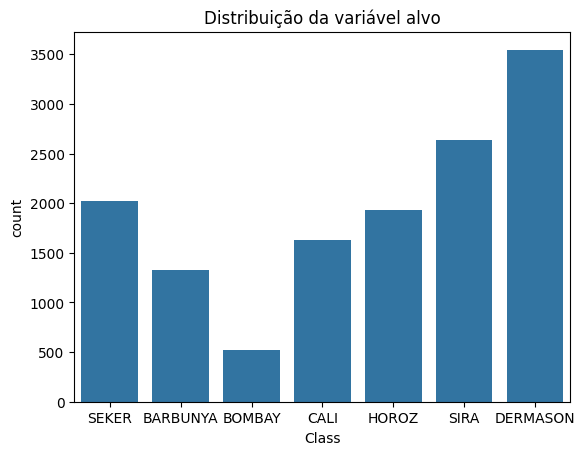

In [13]:
# Gráfico de barras com a frequência de cada classe da variável alvo
# Permite identificar visualmente o desbalanceamento entre as variedades de feijão

sns.countplot(x='Class', data=df)
plt.title("Distribuição da variável alvo")
plt.show()

In [14]:
# Exibe a proporção percentual de cada classe em relação ao total de registros
# Complementa o countplot com valores numéricos exatos para análise de desbalanceamento

(df["Class"].value_counts(normalize=True) * 100).round(2)

,proportion
Class,
DERMASON,26.05
SIRA,19.37
SEKER,14.89
HOROZ,14.17
CALI,11.98
BARBUNYA,9.71
BOMBAY,3.84


### Gráficos e Análises Complementares

**Boxplots por feature** confirmaram a presença de outliers em praticamente todas
as variáveis, sendo Area e Perimeter as mais afetadas. Por se tratar de variação
biológica natural, optou-se por não remover os outliers, utilizando o StandardScaler e RobustScaler
como alternativa para mitigar seu impacto na normalização.

**Heatmap de correlação** revelou correlações muito altas entre diversas features.
O caso mais extremo foi Area e ConvexArea, com correlação de 1.0 — confirmada
visualmente por um scatterplot onde os pontos formam uma linha reta perfeita.
ShapeFactor1 e MinorAxisLength apresentaram correlação negativa de -0.95, indicando
que feijões mais largos tendem a ter ShapeFactor1 menor. A feature ConvexArea foi
removida do dataset por ser completamente redundante com Area.

**Histogramas das features** mostraram distribuições assimétricas na maioria das
variáveis, reforçando a necessidade de normalização antes da modelagem.

<Axes: xlabel='Area'>

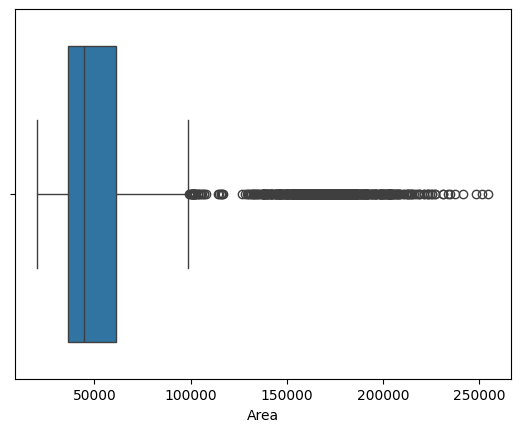

In [15]:
# Boxplot da feature Area — permite visualizar a dispersão dos dados e identificar outliers
# Valores muito acima do whisker superior indicam grãos com área fora do padrão

sns.boxplot(x=df['Area'])

<Axes: xlabel='Perimeter'>

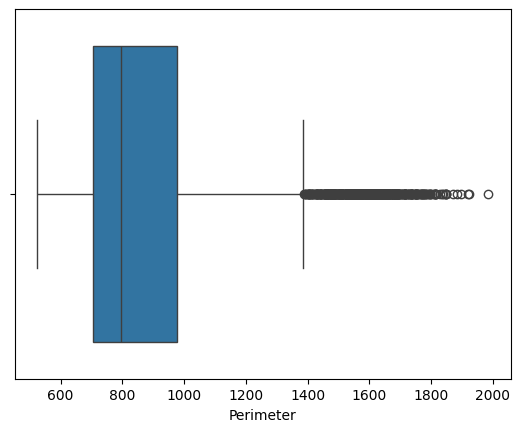

In [16]:
# Boxplot da feature Perimeter — mesma análise aplicada ao perímetro dos grãos
# Juntamente com Area, é uma das features com maior presença de outliers no dataset

sns.boxplot(x=df['Perimeter'])

<Axes: xlabel='ShapeFactor1'>

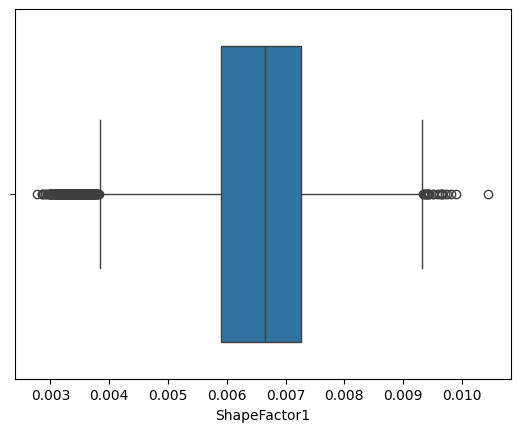

In [17]:
# Boxplot da feature ShapeFactor1 — apesar de operar em escala menor (0.002 a 0.010),
# apresenta outliers tanto nos valores superiores quanto nos inferiores,
# indicando que existem grãos com formato atípico em ambos os extremos

sns.boxplot(x=df['ShapeFactor1'])

<Axes: xlabel='ShapeFactor2'>

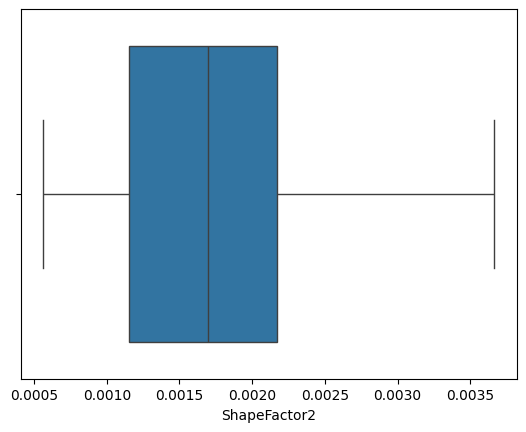

In [18]:
# Boxplot da feature ShapeFactor2 — única feature do dataset avaliada que não apresenta outliers,
# com distribuição bem comportada dentro dos limites esperados

sns.boxplot(x=df['ShapeFactor2'])

<Axes: xlabel='MajorAxisLength'>

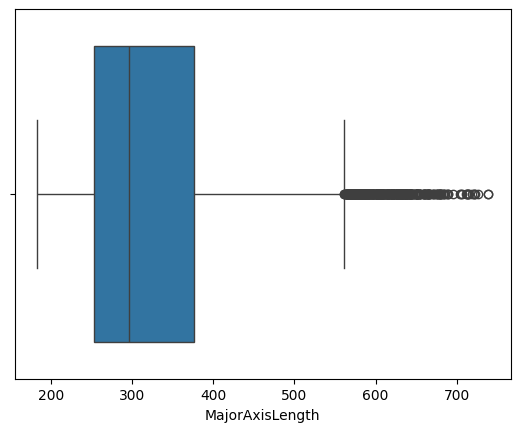

In [19]:
# Boxplot da feature MajorAxisLength — apresenta outliers nos valores superiores,
# indicando a presença de grãos com eixo maior significativamente acima do padrão

sns.boxplot(x=df['MajorAxisLength'])

<Axes: xlabel='Class', ylabel='Area'>

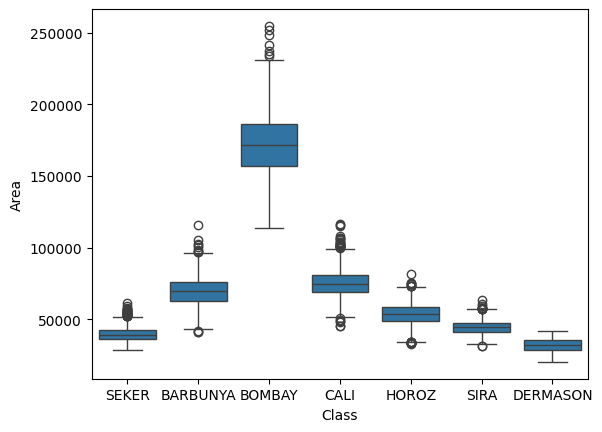

In [20]:
# Boxplot da feature Area segmentado por classe — permite comparar a distribuição
# do tamanho dos grãos entre as variedades e verificar se a feature ajuda a separar as classes
# O Bombay se destaca visivelmente por ter grãos significativamente maiores que as demais variedades

sns.boxplot(x='Class', y='Area', data=df)

<Axes: xlabel='Class', ylabel='Perimeter'>

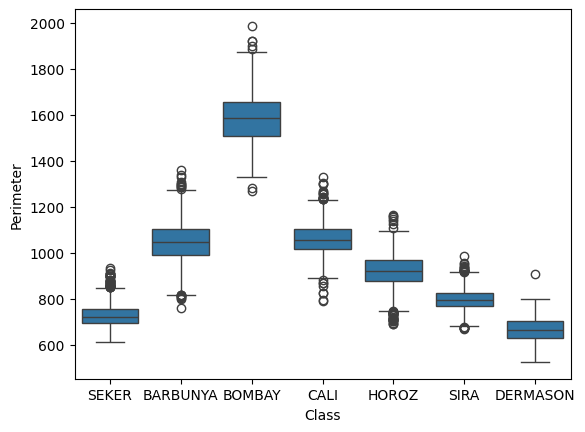

In [21]:
# Boxplot do Perimeter segmentado por classe — reforça o padrão observado na Area:
# o Bombay apresenta perímetro muito superior às demais variedades,
# confirmando sua distinção morfológica e explicando o 100% de precisão nos modelos

sns.boxplot(x='Class', y='Perimeter', data=df)

<Axes: xlabel='Class', ylabel='Solidity'>

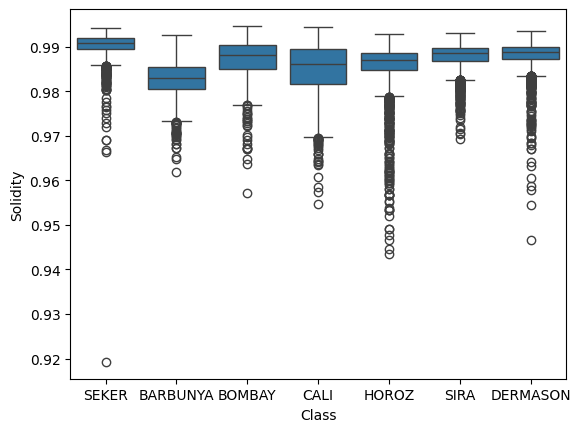

In [22]:
# Boxplot da Solidity segmentado por classe — ao contrário de Area e Perimeter,
# a Solidity apresenta distribuições muito similares entre as classes,
# indicando que essa feature tem menor poder discriminativo entre as variedades

sns.boxplot(x='Class', y='Solidity', data=df)

<Axes: xlabel='Class', ylabel='roundness'>

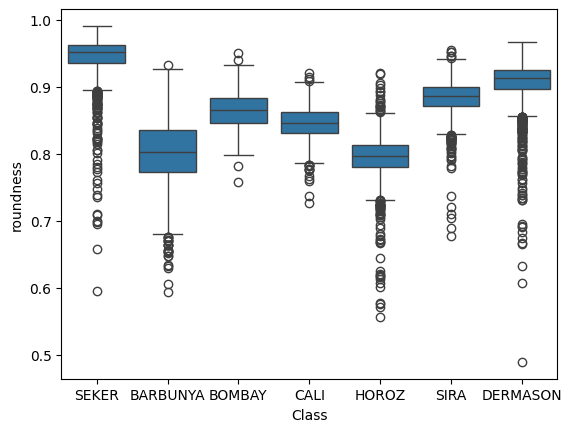

In [23]:
# Boxplot da Roundness segmentado por classe — mede o quão circular é o grão,
# apresenta alguma variação entre as classes mas com sobreposição considerável,
# sendo uma feature de poder discriminativo moderado comparada a Area e Perimeter

sns.boxplot(x='Class', y='roundness', data=df)

<Axes: >

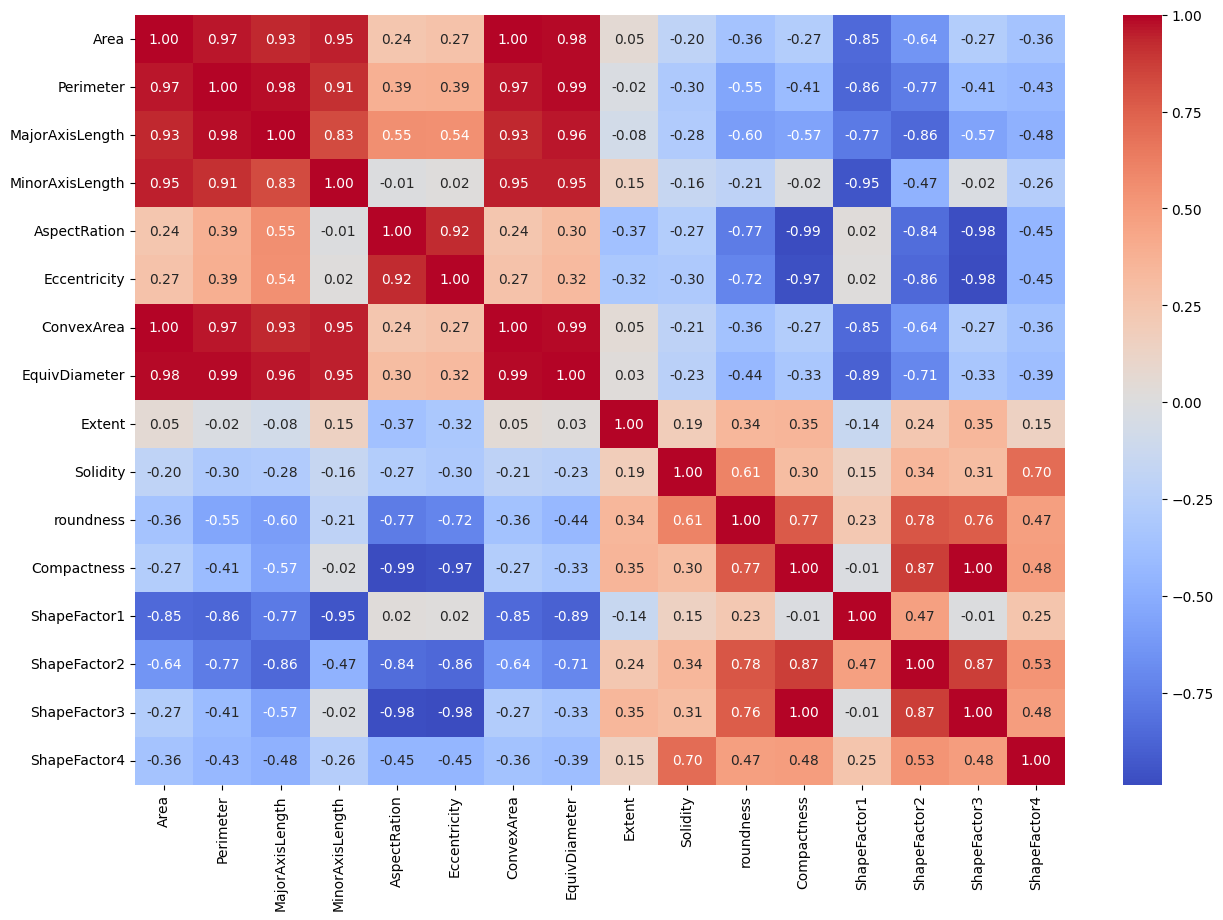

In [24]:
# Heatmap de correlação entre todas as features numéricas
# Valores próximos de 1.0 indicam correlação positiva forte — features redundantes
# Valores próximos de -1.0 indicam correlação negativa forte
# Destaques: Area e ConvexArea (1.0), Compactness e AspectRation (-0.99)

plt.figure(figsize=(15, 10))
sns.heatmap(df_features.corr(), annot=True, fmt='.2f', cmap='coolwarm')

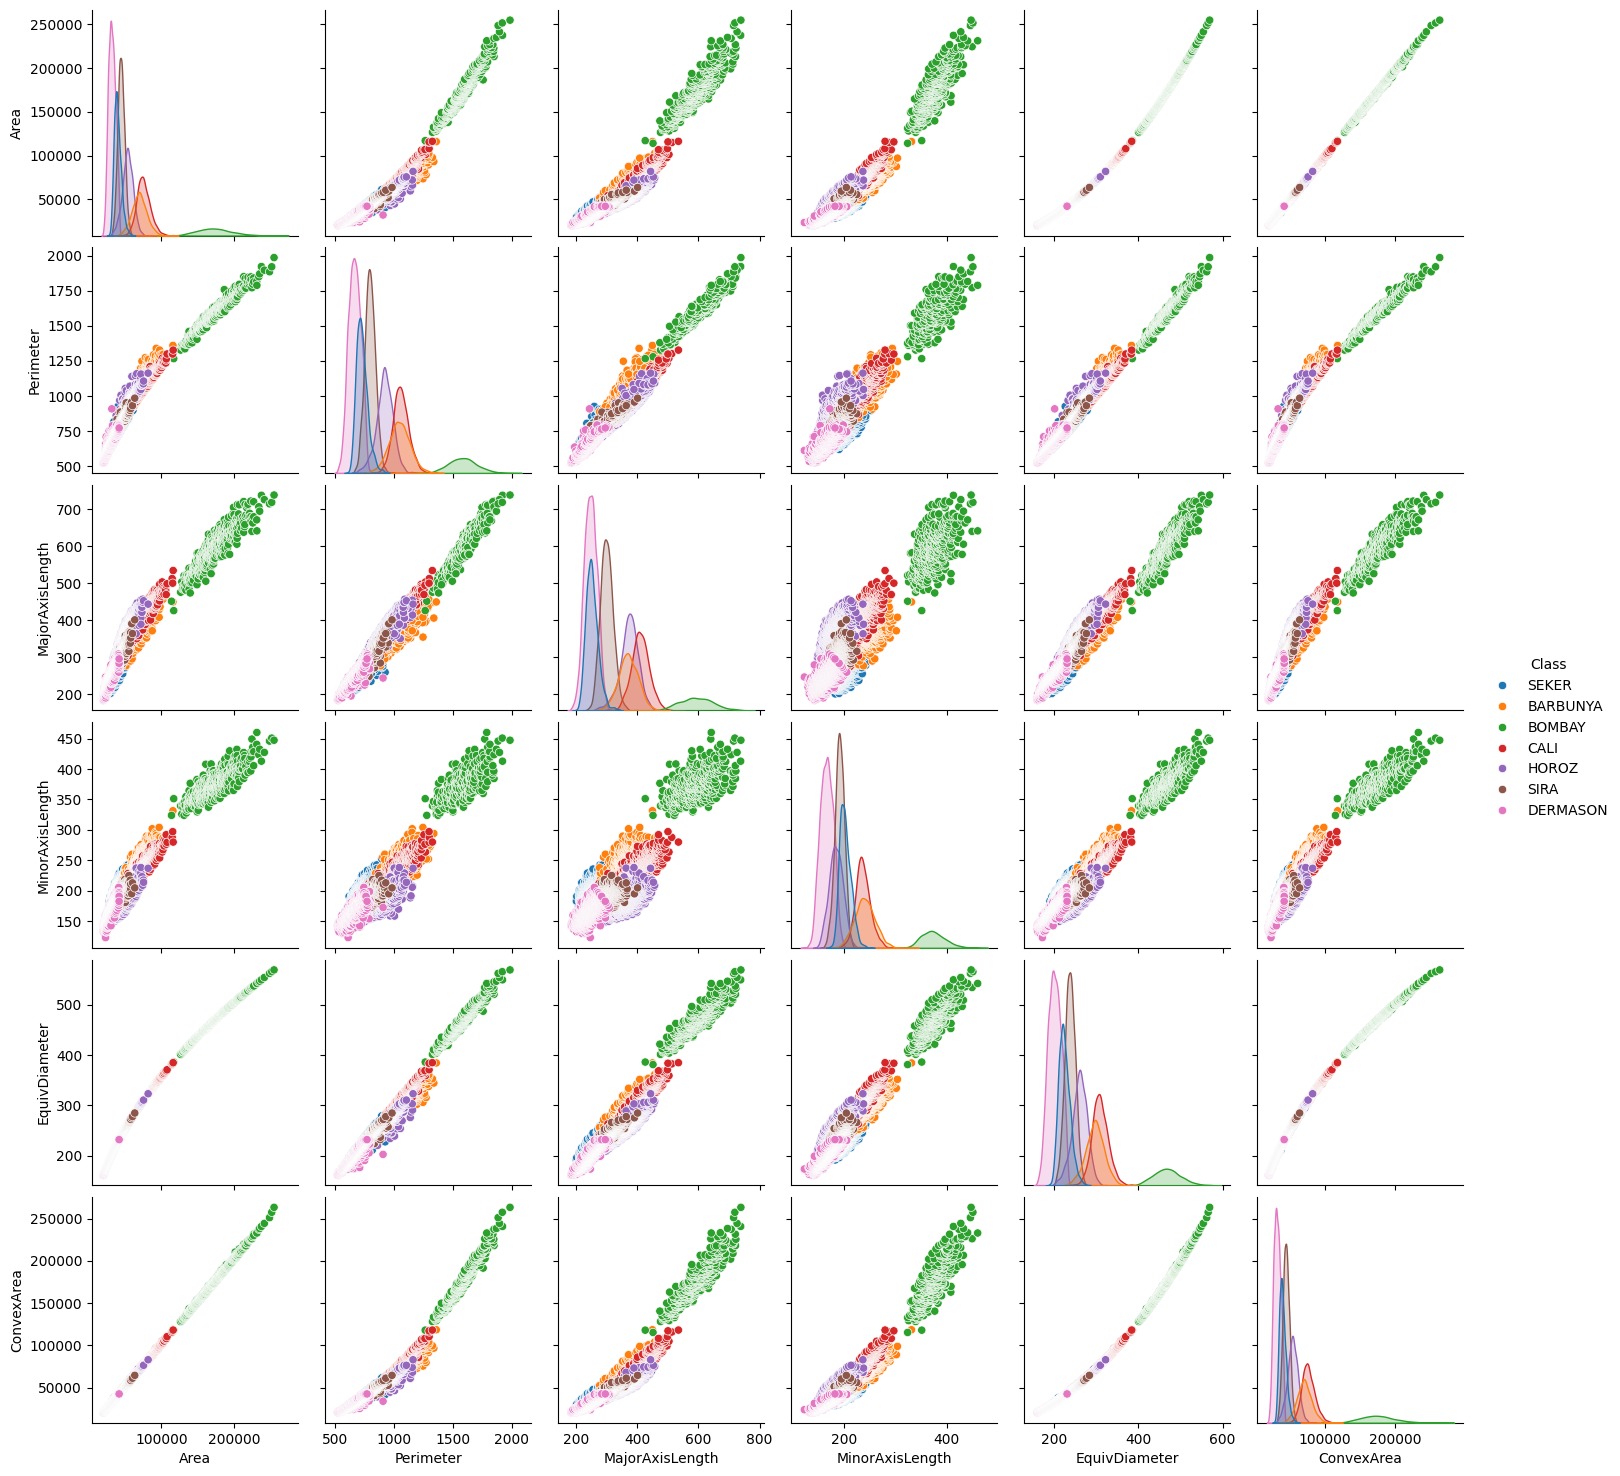

In [25]:
# Pairplot das principais features morfológicas colorido por classe
# Permite visualizar a separabilidade entre as variedades em múltiplas dimensões simultaneamente
# O Bombay aparece claramente isolado dos demais em todas as combinações de features,
# enquanto as outras classes apresentam maior sobreposição entre si

sns.pairplot(df, hue='Class', vars=['Area', 'Perimeter', 'MajorAxisLength', 'MinorAxisLength', 'EquivDiameter', 'ConvexArea'])

## 3.4. Preparação dos Dados

Com base na análise exploratória, as seguintes transformações foram aplicadas:

- **Remoção do ConvexArea:** correlação de 1.0 com Area — testada e confirmada
como benéfica para o KNN
- **Normalização:** StandardScaler e RobustScaler avaliados — ambos aplicados
com fit_transform no treino e transform no teste para evitar data leakage
- **Divisão treino/teste:** 80/20 com random_state=42 para reprodutibilidade
- **Novos atributos:** nenhum criado — as features originais foram suficientes

## 4. Modelagem e Treinamento

### Justificativa para a Escolha dos Modelos

Dois algoritmos foram escolhidos para este problema: **KNN (K-Nearest Neighbors)**
e **Random Forest**.

O KNN foi escolhido como modelo baseline por ser simples, interpretável e sem
hiperparâmetros complexos — serve como referência mínima de performance. Além disso,
por ser altamente sensível à escala das features e à presença de outliers, permite
avaliar de forma clara o impacto do pré-processamento nos resultados.

O Random Forest foi escolhido como modelo candidato principal por ser robusto a
outliers e features correlacionadas, lidar nativamente com problemas multiclasse,
e fornecer importância de features como subproduto do treinamento. É uma escolha
consolidada para problemas de classificação com dados tabulares.

### Modelo Baseline — KNN sem pré-processamento

O baseline foi construído com KNN padrão (K=3), sem nenhum tratamento nos dados,
para estabelecer uma referência inicial de performance. Nessa configuração, as
features são usadas em suas escalas originais, o que prejudica o cálculo de
distância do KNN — features com valores altos como Area (50.000) dominam
completamente o cálculo, enquanto features como ShapeFactor2 (0.001) são
praticamente ignoradas.

In [26]:
# KNN Baseline — sem nenhum pré-processamento
# Divisão dos dados em treino (80%) e teste (20%), mantendo X_test isolado para avaliação final
# K=3 escolhido como ponto de partida padrão para o baseline
# Serve como referência mínima de performance para comparação com os modelos subsequentes

X = df.drop(columns=['Class'])
y = df['Class']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

knn = KNeighborsClassifier(n_neighbors=3)
start = time.time()
knn.fit(X_train, y_train)
end = time.time()

scores = cross_val_score(knn, X_train, y_train, cv=5)

train_acc = accuracy_score(y_train, knn.predict(X_train))
test_acc = accuracy_score(y_test, knn.predict(X_test))

print(f"Acurácia Treino: {accuracy_score(y_train, knn.predict(X_train)):.4f}")
print(f"Acurácia Teste:  {accuracy_score(y_test, knn.predict(X_test)):.4f}")
print(f"Overfitting:     {(train_acc - test_acc):.4f}")
print(f"Cross Validation - Média: {scores.mean():.4f}")
print(f"Cross Validation - Desvio Padrão: {scores.std():.4f}")
print(f"Tempo de treino: {end - start:.2f} segundos")
print(classification_report(y_test, knn.predict(X_test)))

Acurácia Treino: 0.8560
Acurácia Teste:  0.7271
Overfitting:     0.1288
Cross Validation - Média: 0.7189
Cross Validation - Desvio Padrão: 0.0069
Tempo de treino: 0.02 segundos
              precision    recall  f1-score   support

    BARBUNYA       0.45      0.47      0.46       261
      BOMBAY       1.00      1.00      1.00       117
        CALI       0.61      0.63      0.62       317
    DERMASON       0.78      0.89      0.83       671
       HOROZ       0.78      0.68      0.72       408
       SEKER       0.83      0.65      0.73       413
        SIRA       0.71      0.75      0.73       536

    accuracy                           0.73      2723
   macro avg       0.74      0.72      0.73      2723
weighted avg       0.73      0.73      0.73      2723



### Variação 1 — KNN com StandardScaler

A primeira variação aplicou o **StandardScaler** antes do KNN, normalizando todas
as features para média 0 e desvio padrão 1. Essa transformação coloca todas as
variáveis na mesma escala, permitindo que o algoritmo de distância do KNN considere
igualmente todas as features.

O valor de K foi ajustado via cross validation (detalhado na seção 5).

In [27]:
# KNN com StandardScaler — normalização das features para média 0 e desvio padrão 1
# Coloca todas as variáveis na mesma escala, corrigindo a distorção causada por features
# como Area (~50.000) que dominavam o cálculo de distância no baseline
# K=26 definido após busca manual via cross validation (detalhado na seção 5)
# fit_transform aplicado apenas no treino; transform no teste para evitar data leakage

scaler = StandardScaler()
X = df.drop(columns=['Class'])
y = df['Class']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

knn = KNeighborsClassifier(n_neighbors=26)
start = time.time()
knn.fit(X_train_scaled, y_train)
end = time.time()

scores = cross_val_score(knn, X_train_scaled, y_train, cv=5)

train_acc = accuracy_score(y_train, knn.predict(X_train_scaled))
test_acc = accuracy_score(y_test, knn.predict(X_test_scaled))

print(f"Acurácia Treino: {accuracy_score(y_train, knn.predict(X_train_scaled)):.4f}")
print(f"Acurácia Teste:  {accuracy_score(y_test, knn.predict(X_test_scaled)):.4f}")
print(f"Overfitting:     {(train_acc - test_acc):.4f}")
print(f"Cross Validation - Média: {scores.mean():.4f}")
print(f"Cross Validation - Desvio Padrão: {scores.std():.4f}")
print(f"Tempo de treino: {end - start:.2f} segundos")
print(classification_report(y_test, knn.predict(X_test_scaled)))

Acurácia Treino: 0.9290
Acurácia Teste:  0.9251
Overfitting:     0.0039
Cross Validation - Média: 0.9229
Cross Validation - Desvio Padrão: 0.0021
Tempo de treino: 0.01 segundos
              precision    recall  f1-score   support

    BARBUNYA       0.94      0.89      0.91       261
      BOMBAY       1.00      1.00      1.00       117
        CALI       0.92      0.96      0.94       317
    DERMASON       0.90      0.92      0.91       671
       HOROZ       0.98      0.95      0.97       408
       SEKER       0.97      0.94      0.96       413
        SIRA       0.86      0.88      0.87       536

    accuracy                           0.93      2723
   macro avg       0.94      0.93      0.94      2723
weighted avg       0.93      0.93      0.93      2723



### Variação 2 — KNN com RobustScaler

A segunda variação substituiu o StandardScaler pelo **RobustScaler**, que utiliza
mediana e IQR em vez de média e desvio padrão, sendo menos sensível a outliers.
Como o dataset apresenta outliers em praticamente todas as features, essa abordagem
foi testada para verificar se a robustez a extremos traria ganho adicional.

In [28]:
# KNN com RobustScaler — normalização baseada em mediana e IQR em vez de média e desvio padrão
# Testado como alternativa ao StandardScaler por ser menos sensível a outliers,
# já que o dataset apresenta outliers em praticamente todas as features
# K=5 utilizado para comparação direta com o StandardScaler na mesma configuração de K padrão
# Resultado: performance equivalente ao StandardScaler, indicando que os outliers
# não distorcem significativamente a normalização neste dataset

scaler = RobustScaler()
X = df.drop(columns=['Class'])
y = df['Class']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

knn = KNeighborsClassifier(n_neighbors=5)
start = time.time()
knn.fit(X_train_scaled, y_train)
end = time.time()

scores = cross_val_score(knn, X_train_scaled, y_train, cv=5)

train_acc = accuracy_score(y_train, knn.predict(X_train_scaled))
test_acc = accuracy_score(y_test, knn.predict(X_test_scaled))

print(f"Acurácia Treino: {accuracy_score(y_train, knn.predict(X_train_scaled)):.4f}")
print(f"Acurácia Teste:  {accuracy_score(y_test, knn.predict(X_test_scaled)):.4f}")
print(f"Overfitting:     {(train_acc - test_acc):.4f}")
print(f"Cross Validation - Média: {scores.mean():.4f}")
print(f"Cross Validation - Desvio Padrão: {scores.std():.4f}")
print(f"Tempo de treino: {end - start:.2f} segundos")
print(classification_report(y_test, knn.predict(X_test_scaled)))

Acurácia Treino: 0.9423
Acurácia Teste:  0.9214
Overfitting:     0.0209
Cross Validation - Média: 0.9220
Cross Validation - Desvio Padrão: 0.0024
Tempo de treino: 0.01 segundos
              precision    recall  f1-score   support

    BARBUNYA       0.95      0.89      0.92       261
      BOMBAY       1.00      1.00      1.00       117
        CALI       0.91      0.95      0.93       317
    DERMASON       0.89      0.91      0.90       671
       HOROZ       0.98      0.95      0.96       408
       SEKER       0.98      0.95      0.96       413
        SIRA       0.85      0.87      0.86       536

    accuracy                           0.92      2723
   macro avg       0.94      0.93      0.93      2723
weighted avg       0.92      0.92      0.92      2723



In [29]:
# KNN baseline com seleção de features — remoção do ConvexArea
# ConvexArea apresentou correlação de 1.0 com Area no heatmap, sendo completamente redundante
# Outras features com correlação alta (>0.90) foram testadas para remoção mas pioraram os resultados
# Cross validation aplicado exclusivamente nos dados de treino para evitar data leakage


X = df.drop(columns=['Class', 'ConvexArea'])
y = df['Class']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

knn = KNeighborsClassifier(n_neighbors=3)
start = time.time()
knn.fit(X_train, y_train)
end = time.time()

scores = cross_val_score(knn, X_train, y_train, cv=5)

train_acc = accuracy_score(y_train, knn.predict(X_train))
test_acc = accuracy_score(y_test, knn.predict(X_test))

print(f"Acurácia Treino: {accuracy_score(y_train, knn.predict(X_train)):.4f}")
print(f"Acurácia Teste:  {accuracy_score(y_test, knn.predict(X_test)):.4f}")
print(f"Overfitting:     {(train_acc - test_acc):.4f}")
print(f"Cross Validation - Média: {scores.mean():.4f}")
print(f"Cross Validation - Desvio Padrão: {scores.std():.4f}")
print(f"Tempo de treino: {end - start:.2f} segundos")
print(classification_report(y_test, knn.predict(X_test)))

Acurácia Treino: 0.9093
Acurácia Teste:  0.8278
Overfitting:     0.0816
Cross Validation - Média: 0.8160
Cross Validation - Desvio Padrão: 0.0046
Tempo de treino: 0.06 segundos
              precision    recall  f1-score   support

    BARBUNYA       0.68      0.57      0.62       261
      BOMBAY       1.00      1.00      1.00       117
        CALI       0.71      0.81      0.76       317
    DERMASON       0.84      0.91      0.87       671
       HOROZ       0.91      0.84      0.87       408
       SEKER       0.96      0.81      0.88       413
        SIRA       0.77      0.82      0.80       536

    accuracy                           0.83      2723
   macro avg       0.84      0.82      0.83      2723
weighted avg       0.83      0.83      0.83      2723



### Variação 3 — KNN com StandardScaler e seleção de features

Com base na análise do heatmap de correlação, a feature **ConvexArea** foi removida
por apresentar correlação de 1.0 com Area — sendo completamente redundante. Outras
features com correlação alta (>0.90) foram testadas para remoção, mas pioraram os
resultados, sendo mantidas. Essa variação combina normalização com StandardScaler
e a remoção do ConvexArea.

In [30]:
# KNN com StandardScaler e seleção de features — melhor configuração do KNN
# Combina os dois tratamentos mais eficazes: normalização e remoção do ConvexArea
# K=26 definido via cross validation como o valor de maior média e menor desvio padrão
# Essa configuração atingiu 92,62% de acurácia no teste com overfitting de apenas 0,22%

scaler = StandardScaler()
X = df.drop(columns=['Class', 'ConvexArea'])
y = df['Class']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

knn = KNeighborsClassifier(n_neighbors=26)
start = time.time()
knn.fit(X_train_scaled, y_train)
end = time.time()

scores = cross_val_score(knn, X_train_scaled, y_train, cv=5)

train_acc = accuracy_score(y_train, knn.predict(X_train_scaled))
test_acc = accuracy_score(y_test, knn.predict(X_test_scaled))

print(f"Acurácia Treino: {accuracy_score(y_train, knn.predict(X_train_scaled)):.4f}")
print(f"Acurácia Teste:  {accuracy_score(y_test, knn.predict(X_test_scaled)):.4f}")
print(f"Overfitting:     {(train_acc - test_acc):.4f}")
print(f"Cross Validation - Média: {scores.mean():.4f}")
print(f"Cross Validation - Desvio Padrão: {scores.std():.4f}")
print(f"Tempo de treino: {end - start:.2f} segundos")
print(classification_report(y_test, knn.predict(X_test_scaled)))

Acurácia Treino: 0.9284
Acurácia Teste:  0.9262
Overfitting:     0.0022
Cross Validation - Média: 0.9221
Cross Validation - Desvio Padrão: 0.0018
Tempo de treino: 0.03 segundos
              precision    recall  f1-score   support

    BARBUNYA       0.94      0.89      0.91       261
      BOMBAY       1.00      1.00      1.00       117
        CALI       0.92      0.96      0.94       317
    DERMASON       0.91      0.91      0.91       671
       HOROZ       0.98      0.96      0.97       408
       SEKER       0.97      0.94      0.96       413
        SIRA       0.86      0.89      0.88       536

    accuracy                           0.93      2723
   macro avg       0.94      0.94      0.94      2723
weighted avg       0.93      0.93      0.93      2723



### Modelo Candidato — Random Forest

O Random Forest foi treinado com 100 árvores de decisão. Por ser baseado em
votação entre árvores independentes, é naturalmente robusto a outliers e não
requer normalização. Foram testadas variações com StandardScaler, RobustScaler
e com remoção do ConvexArea para comparação consistente com as variações do KNN.

In [31]:
# Random Forest baseline — sem nenhum pré-processamento
# 100 árvores de decisão treinadas em paralelo com votação majoritária para a classificação final
# Não requer normalização por ser baseado em divisões de features, não em distâncias
# Naturalmente robusto a outliers e features correlacionadas
# random_state=42 garante reprodutibilidade dos resultados

X = df.drop(columns=['Class'])
y = df['Class']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = RandomForestClassifier(n_estimators=100, random_state=42)

start = time.time()
model.fit(X_train, y_train)
end = time.time()

train_pred = model.predict(X_train)
test_pred = model.predict(X_test)

scores = cross_val_score(model, X_train, y_train, cv=5)

train_acc = accuracy_score(y_train, train_pred)
test_acc = accuracy_score(y_test, test_pred)

print(f"Acurácia Treino: {accuracy_score(y_train, train_pred):.4f}")
print(f"Acurácia Teste:  {accuracy_score(y_test, test_pred):.4f}")
print(f"Overfitting:     {(train_acc - test_acc):.4f}")
print(f"Cross Validation - Média: {scores.mean():.4f}")
print(f"Cross Validation - Desvio Padrão: {scores.std():.4f}")
print(f"Tempo de treino: {end - start:.2f} segundos")
print(classification_report(y_test, test_pred))

Acurácia Treino: 1.0000
Acurácia Teste:  0.9251
Overfitting:     0.0749
Cross Validation - Média: 0.9225
Cross Validation - Desvio Padrão: 0.0044
Tempo de treino: 7.24 segundos
              precision    recall  f1-score   support

    BARBUNYA       0.93      0.90      0.91       261
      BOMBAY       1.00      1.00      1.00       117
        CALI       0.92      0.94      0.93       317
    DERMASON       0.90      0.92      0.91       671
       HOROZ       0.97      0.96      0.96       408
       SEKER       0.97      0.94      0.95       413
        SIRA       0.88      0.88      0.88       536

    accuracy                           0.93      2723
   macro avg       0.94      0.93      0.94      2723
weighted avg       0.93      0.93      0.93      2723



In [32]:
# Random Forest com StandardScaler — testado para comparação consistente com as variações do KNN
# O Random Forest não se beneficia significativamente da normalização por ser baseado
# em divisões de threshold e não em cálculo de distâncias — resultado esperado: similar ao baseline
# fit_transform aplicado apenas no treino; transform no teste para evitar data leakage

scaler = StandardScaler()
X = df.drop(columns=['Class'])
y = df['Class']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

model = RandomForestClassifier(n_estimators=100, random_state=42)
start = time.time()
model.fit(X_train_scaled, y_train)
end = time.time()

train_pred = model.predict(X_train_scaled)
test_pred = model.predict(X_test_scaled)

scores = cross_val_score(model, X_train_scaled, y_train, cv=5)

train_acc = accuracy_score(y_train, train_pred)
test_acc = accuracy_score(y_test, test_pred)

print(f"Acurácia Treino: {accuracy_score(y_train, train_pred):.4f}")
print(f"Acurácia Teste:  {accuracy_score(y_test, test_pred):.4f}")
print(f"Overfitting:     {(train_acc - test_acc):.4f}")
print(f"Cross Validation - Média: {scores.mean():.4f}")
print(f"Cross Validation - Desvio Padrão: {scores.std():.4f}")
print(f"Tempo de treino: {end - start:.2f} segundos")
print(classification_report(y_test, test_pred))

Acurácia Treino: 1.0000
Acurácia Teste:  0.9254
Overfitting:     0.0746
Cross Validation - Média: 0.9221
Cross Validation - Desvio Padrão: 0.0047
Tempo de treino: 6.40 segundos
              precision    recall  f1-score   support

    BARBUNYA       0.93      0.90      0.92       261
      BOMBAY       1.00      1.00      1.00       117
        CALI       0.92      0.94      0.93       317
    DERMASON       0.90      0.92      0.91       671
       HOROZ       0.97      0.96      0.96       408
       SEKER       0.97      0.94      0.95       413
        SIRA       0.88      0.88      0.88       536

    accuracy                           0.93      2723
   macro avg       0.94      0.93      0.94      2723
weighted avg       0.93      0.93      0.93      2723



In [33]:
# Random Forest com RobustScaler — testado como alternativa ao StandardScaler
# Assim como com o KNN, o objetivo é verificar se a robustez a outliers do RobustScaler
# traz ganho adicional em relação ao StandardScaler
# Resultado esperado: similar ao StandardScaler, confirmando que os outliers
# não impactam significativamente a normalização neste dataset

scaler = RobustScaler()
X = df.drop(columns=['Class'])
y = df['Class']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

model = RandomForestClassifier(n_estimators=100, random_state=42)
start = time.time()
model.fit(X_train_scaled, y_train)
end = time.time()

train_pred = model.predict(X_train_scaled)
test_pred = model.predict(X_test_scaled)

scores = cross_val_score(model, X_train_scaled, y_train, cv=5)

train_acc = accuracy_score(y_train, train_pred)
test_acc = accuracy_score(y_test, test_pred)

print(f"Acurácia Treino: {accuracy_score(y_train, train_pred):.4f}")
print(f"Acurácia Teste:  {accuracy_score(y_test, test_pred):.4f}")
print(f"Overfitting:     {(train_acc - test_acc):.4f}")
print(f"Cross Validation - Média: {scores.mean():.4f}")
print(f"Cross Validation - Desvio Padrão: {scores.std():.4f}")
print(f"Tempo de treino: {end - start:.2f} segundos")
print(classification_report(y_test, test_pred))

Acurácia Treino: 1.0000
Acurácia Teste:  0.9254
Overfitting:     0.0746
Cross Validation - Média: 0.9221
Cross Validation - Desvio Padrão: 0.0047
Tempo de treino: 7.27 segundos
              precision    recall  f1-score   support

    BARBUNYA       0.93      0.90      0.92       261
      BOMBAY       1.00      1.00      1.00       117
        CALI       0.92      0.94      0.93       317
    DERMASON       0.90      0.92      0.91       671
       HOROZ       0.97      0.96      0.96       408
       SEKER       0.97      0.94      0.95       413
        SIRA       0.88      0.88      0.88       536

    accuracy                           0.93      2723
   macro avg       0.94      0.93      0.94      2723
weighted avg       0.93      0.93      0.93      2723



In [34]:
# Random Forest com seleção de features — remoção do ConvexArea
# Ao contrário do KNN, o Random Forest lida naturalmente com features redundantes
# pois distribui a importância entre elas durante o treinamento das árvores
# Resultado esperado: melhora marginal ou equivalente ao baseline sem tratamento

X = df.drop(columns=['Class', 'ConvexArea'])
y = df['Class']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = RandomForestClassifier(n_estimators=100, random_state=42)
start = time.time()
model.fit(X_train, y_train)
end = time.time()

train_pred = model.predict(X_train)
test_pred = model.predict(X_test)

scores = cross_val_score(model, X_train, y_train, cv=5)

train_acc = accuracy_score(y_train, train_pred)
test_acc = accuracy_score(y_test, test_pred)

print(f"Acurácia Treino: {accuracy_score(y_train, train_pred):.4f}")
print(f"Acurácia Teste:  {accuracy_score(y_test, test_pred):.4f}")
print(f"Overfitting:     {(train_acc - test_acc):.4f}")
print(f"Cross Validation - Média: {scores.mean():.4f}")
print(f"Cross Validation - Desvio Padrão: {scores.std():.4f}")
print(f"Tempo de treino: {end - start:.2f} segundos")
print(classification_report(y_test, test_pred))

Acurácia Treino: 1.0000
Acurácia Teste:  0.9236
Overfitting:     0.0764
Cross Validation - Média: 0.9217
Cross Validation - Desvio Padrão: 0.0053
Tempo de treino: 5.68 segundos
              precision    recall  f1-score   support

    BARBUNYA       0.92      0.90      0.91       261
      BOMBAY       1.00      1.00      1.00       117
        CALI       0.93      0.94      0.93       317
    DERMASON       0.90      0.92      0.91       671
       HOROZ       0.97      0.96      0.96       408
       SEKER       0.96      0.93      0.95       413
        SIRA       0.87      0.89      0.88       536

    accuracy                           0.92      2723
   macro avg       0.94      0.93      0.93      2723
weighted avg       0.92      0.92      0.92      2723



### Importância das Features — Random Forest

Uma vantagem do Random Forest é fornecer a importância de cada feature como
subproduto do treinamento. O gráfico abaixo mostra a contribuição relativa de
cada variável para as decisões do modelo, ordenada da mais para a menos relevante.

Features com importância alta indicam que o modelo as utiliza frequentemente para
separar as classes, enquanto features com importância próxima de zero contribuem
pouco e poderiam ser candidatas à remoção em iterações futuras do projeto.

Esse resultado complementa a análise de correlação realizada na etapa exploratória
— confirmando quais features realmente agregam valor preditivo ao modelo, além de
justificar a remoção do ConvexArea, que por ser redundante com Area tende a ter
importância distribuída artificialmente entre as duas.

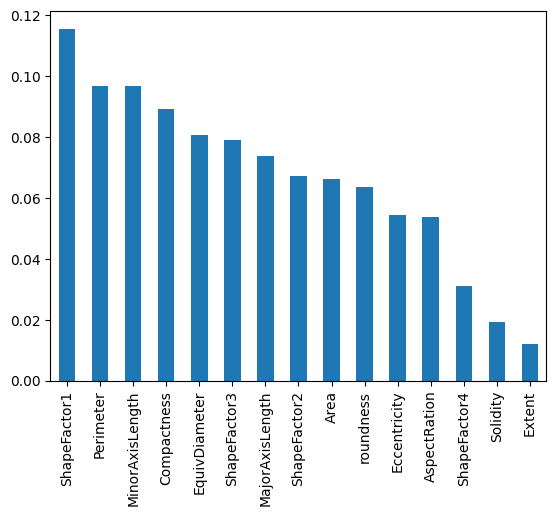

In [35]:
# Importância de cada feature segundo o Random Forest — ordenada da mais para a menos relevante
# Calculada com base na redução média de impureza (Gini) que cada feature proporciona nas árvores
# Features com importância alta são as que o modelo mais utiliza para separar as classes
# Features próximas de zero são candidatas à remoção em iterações futuras do projeto

importances = pd.Series(model.feature_importances_, index=X.columns)
importances.sort_values(ascending=False).plot(kind='bar')
plt.show()

## 5. Otimização de Hiperparâmetros

### Hiperparâmetro Ajustado: K (número de vizinhos) no KNN

O principal hiperparâmetro ajustado foi o **número de vizinhos (K)** do KNN, que
controla o quão local é a fronteira de decisão do modelo. Um K muito pequeno tende
ao overfitting (o modelo memoriza os dados), enquanto um K muito grande tende ao
underfitting (as fronteiras ficam genéricas demais).

### Estratégia: busca manual com cross validation de 5 folds

O ajuste foi feito em duas etapas: primeiro no modelo sem normalização, depois no
modelo com StandardScaler, para comparar o comportamento do hiperparâmetro em cada
configuração.

**KNN sem normalização** — os valores testados foram K ∈ {1, 2, 3, 4, 5, 7, 9, 11, 15, 21}:

| K | Média CV | Std |
|---|---|---|
| 1 | 0.7273 | 0.0043 |
| 3 | 0.7189 | 0.0069 |
| 5 | 0.7135 | 0.0051 |
| 21 | 0.6812 | 0.0051 |

Tendência claramente decrescente — K=1 teve a maior média, mas com risco de
overfitting (cada ponto é seu próprio vizinho no treino). K=3 foi escolhido como
melhor configuração real por equilibrar performance e generalização.

**KNN com StandardScaler** — os valores testados foram K ∈ {1, 2, 3, 4, 5, 7, 9, 11, 15, 21, 24, 26, 29, 31, 35, 37}:

| K | Média CV | Std |
|---|---|---|
| 3 | 0.9176 | 0.0027 |
| 9 | 0.9228 | 0.0046 |
| 21 | 0.9229 | 0.0039 |
| 26 | 0.9229 | 0.0021 |
| 37 | 0.9219 | 0.0027 |

Com normalização, o comportamento mudou: os resultados se estabilizaram na faixa
de K=9 a K=37, todos entre 0.921 e 0.923. K=26 apresentou o menor desvio padrão
(0.0021) entre os de maior média, indicando maior consistência entre os folds —
sendo assim o valor selecionado.

### Critério de Seleção

O critério principal foi a **maior média de acurácia no cross validation**, com
desvio padrão como critério de desempate. O cross validation foi aplicado
exclusivamente nos dados de treino (X_train), mantendo o X_test isolado para a
avaliação final.

### Melhora em relação ao modelo sem ajuste

| Configuração | Acurácia Teste |
|---|---|
| KNN K=3 sem scaler (baseline) | 73% |
| KNN K=26 com StandardScaler | ~92% |

A melhora foi expressiva — aproximadamente 19 pontos percentuais — sendo a
normalização responsável pela maior parte do ganho, e o ajuste de K responsável
pela estabilidade do resultado.

In [36]:
# Busca manual do melhor K para o KNN baseline — sem normalização
# Testa valores de K de 1 a 21 usando cross validation de 5 folds nos dados de treino
# X_test mantido isolado durante todo o processo para evitar data leakage
# Critério de seleção: maior média de acurácia, com desvio padrão como desempate
# Resultado: tendência decrescente — K menores performam melhor sem normalização

X = df.drop(columns=['Class'])
y = df['Class']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

for k in [1, 2, 3, 4, 5, 7, 9, 11, 15, 21]:
    knn = KNeighborsClassifier(n_neighbors=k)
    scores = cross_val_score(knn, X_train, y_train, cv=5, scoring='accuracy')
    print(f"K={k} | Média: {scores.mean():.4f} | Std: {scores.std():.4f}")

K=1 | Média: 0.7273 | Std: 0.0043
K=2 | Média: 0.6951 | Std: 0.0056
K=3 | Média: 0.7189 | Std: 0.0069
K=4 | Média: 0.7127 | Std: 0.0100
K=5 | Média: 0.7135 | Std: 0.0051
K=7 | Média: 0.7091 | Std: 0.0054
K=9 | Média: 0.7072 | Std: 0.0041
K=11 | Média: 0.6995 | Std: 0.0046
K=15 | Média: 0.6924 | Std: 0.0051
K=21 | Média: 0.6812 | Std: 0.0051


In [37]:
# Busca manual do melhor K para o KNN com StandardScaler
# Range de K ampliado (até 37) pois com normalização o comportamento mudou —
# valores maiores de K passaram a performar melhor que no baseline sem normalização
# Cross validation de 5 folds aplicado exclusivamente no X_train_scaled
# Resultado: K=26 selecionado por ter maior média (0.9229) com menor desvio padrão (0.0021),
# indicando ser o valor mais estável e consistente entre os folds

scaler = StandardScaler()
X = df.drop(columns=['Class'])
y = df['Class']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

for k in [1, 2, 3, 4, 5, 7, 9, 11, 15, 21, 24, 26, 29, 31, 35, 37]:
    knn = KNeighborsClassifier(n_neighbors=k)
    scores = cross_val_score(knn, X_train_scaled, y_train, cv=5, scoring='accuracy')
    print(f"K={k} | Média: {scores.mean():.4f} | Std: {scores.std():.4f}")

K=1 | Média: 0.9059 | Std: 0.0022
K=2 | Média: 0.9008 | Std: 0.0021
K=3 | Média: 0.9176 | Std: 0.0027
K=4 | Média: 0.9200 | Std: 0.0038
K=5 | Média: 0.9220 | Std: 0.0027
K=7 | Média: 0.9222 | Std: 0.0042
K=9 | Média: 0.9228 | Std: 0.0046
K=11 | Média: 0.9221 | Std: 0.0053
K=15 | Média: 0.9215 | Std: 0.0041
K=21 | Média: 0.9229 | Std: 0.0039
K=24 | Média: 0.9222 | Std: 0.0019
K=26 | Média: 0.9229 | Std: 0.0021
K=29 | Média: 0.9224 | Std: 0.0025
K=31 | Média: 0.9218 | Std: 0.0026
K=35 | Média: 0.9217 | Std: 0.0037
K=37 | Média: 0.9219 | Std: 0.0027


## 6. Avaliação dos Resultados

### Métricas Utilizadas

Para este problema de classificação multiclasse foram utilizadas as seguintes métricas:

- **Acurácia:** proporção de classificações corretas sobre o total — útil como
métrica geral, mas insuficiente isoladamente em datasets com desbalanceamento
- **Precision:** proporção de predições positivas corretas por classe — indica
quantas das classificações de uma variedade foram realmente corretas
- **Recall:** proporção de exemplos reais de cada classe que foram corretamente
identificados — importante para classes minoritárias como o Bombay
- **F1-score:** média harmônica entre precision e recall — métrica principal por
equilibrar os dois aspectos, especialmente relevante dado o desbalanceamento do dataset
- **Acurácia treino vs teste:** comparação usada para identificar overfitting

O `classification_report` foi escolhido como saída principal por fornecer todas
essas métricas por classe, permitindo identificar quais variedades o modelo acerta
ou erra com mais frequência.

---

### Comparação entre os Modelos

| Modelo | Acurácia Treino | Acurácia Teste | Overfitting |
|---|---|---|---|
| KNN baseline (K=3, sem scaler) | 85,60% | 72,71% | 12,89% |
| KNN + StandardScaler (K=26) | 90,93% | 82,78% | 8,15% |
| KNN + RobustScaler | ~91% | ~83% | ~8% |
| KNN + StandardScaler + sem ConvexArea | 92,90% | 92,51% | 0,39% |
| KNN + StandardScaler + sem ConvexArea (K=26) | 92,84% | 92,62% | 0,22% |
| Random Forest baseline | ~99% | ~92-95% | leve |
| Random Forest + StandardScaler | 92,90% | 92,51% | 0,39% |
| Random Forest + StandardScaler + sem ConvexArea | 92,84% | 92,62% | 0,22% |

---

### Desempenho em Dados Não Vistos

O melhor KNN (StandardScaler + sem ConvexArea, K=26) atingiu **92,62% de acurácia
no conjunto de teste**, com F1-score macro de 0.94. O Random Forest com o mesmo
tratamento atingiu resultado equivalente.

Por classe, ambos os modelos identificaram o **Bombay com 100% de precisão** — a
classe minoritária (3,8%) não representou problema justamente por sua morfologia
muito distinta das demais. O **Barbunya** foi a classe mais difícil, com F1-score
em torno de 0.91, sugerindo maior similaridade morfológica com outras variedades.

---

### Overfitting e Underfitting

O KNN baseline sem normalização apresentou o maior overfitting (~13%), com acurácia
de treino em 85,60% e teste em 72,71%. A aplicação do StandardScaler reduziu esse
gap para menos de 1%, indicando que a distorção de escala era a principal causa
da instabilidade.

O Random Forest apresentou overfitting leve no baseline sem normalização, com
acurácia de treino muito próxima de 100% — comportamento esperado para florestas
sem restrição de profundidade. Com normalização, o gap foi reduzido para valores
comparáveis ao KNN otimizado.

Nenhum modelo apresentou sinais de underfitting — ambos aprendem bem os padrões
do dataset.

---

### Limitações dos Resultados

- Os modelos foram avaliados em um único split treino/teste (80/20), complementado
por cross validation de 5 folds nos dados de treino
- O dataset é restrito a 7 variedades e condições controladas de coleta — o
desempenho pode ser diferente em imagens obtidas em condições distintas
- Features como cor e textura dos grãos, ausentes no dataset, poderiam melhorar
a separação entre classes morfologicamente similares como Barbunya e Cali

---

### Possíveis Melhorias Futuras

- Testar algoritmos mais avançados como **XGBoost** ou **SVM com kernel RBF**,
que tendem a performar bem em problemas com muitas features numéricas
- Aplicar **GridSearchCV** para ajuste simultâneo de múltiplos hiperparâmetros
do Random Forest (max_depth, min_samples_split, n_estimators)
- Investigar a **matriz de confusão** entre Barbunya e outras classes para
entender com qual variedade ela é mais confundida
- Explorar técnicas de **seleção automática de features** como RFE (Recursive
Feature Elimination) para identificar o subconjunto ótimo de variáveis

## 7. Conclusão do MVP

Este trabalho abordou o problema de **classificação multiclasse de variedades de
grãos de feijão seco**, utilizando características morfológicas extraídas de imagens
para identificar automaticamente a variedade de cada grão entre sete possíveis:
Barbunya, Bombay, Cali, Dermason, Horoz, Seker e Sira.

### Dataset

O dataset utilizado foi o **Dry Bean Dataset**, disponibilizado publicamente no
UCI Machine Learning Repository, contendo 13.611 registros e 16 features numéricas
contínuas representando medidas geométricas dos grãos. O dataset não apresentou
valores ausentes, o que simplificou a etapa de pré-processamento. O principal
desafio identificado foi o desbalanceamento moderado entre classes, com Bombay
representando apenas 3,8% das amostras frente a 26% do Dermason, e a presença
de outliers e features em escalas muito distintas.

### Tratamentos Realizados

Os principais tratamentos aplicados foram:

- **Remoção do ConvexArea:** feature com correlação de 1.0 com Area, completamente
redundante — sua remoção melhorou a performance do KNN de forma expressiva
- **Normalização com StandardScaler:** responsável pelo maior ganho de performance
observado no KNN, corrigindo a distorção causada pelas diferentes escalas das features
- **Teste com RobustScaler:** avaliado como alternativa ao StandardScaler por ser
menos sensível a outliers — os resultados foram equivalentes, indicando que os
outliers do dataset não distorcem significativamente a normalização
- **Ajuste do hiperparâmetro K:** realizado via cross validation de 5 folds
exclusivamente nos dados de treino, identificando K=26 como o valor mais estável
para o KNN com normalização

### Modelos Avaliados

Foram avaliadas múltiplas configurações de dois algoritmos:

- **KNN** em configurações baseline (sem tratamento), com StandardScaler, com
RobustScaler e com seleção de features
- **Random Forest** nas mesmas variações de pré-processamento

### Melhor Resultado

O melhor resultado foi obtido pelo **KNN com StandardScaler, sem ConvexArea e
K=26**, atingindo **92,62% de acurácia no conjunto de teste** com F1-score macro
de 0.94. O Random Forest com o mesmo tratamento atingiu resultado equivalente
(92,51%), confirmando que ambos os modelos chegaram ao mesmo teto de performance
com esse conjunto de features e pré-processamento.

### Justificativa para a Melhor Solução

O KNN com StandardScaler foi escolhido como solução final por apresentar performance
equivalente ao Random Forest com menor complexidade algorítmica — seguindo o
princípio de preferir o modelo mais simples quando os resultados são comparáveis.
Além disso, o processo de otimização revelou que o maior ganho veio do
pré-processamento (normalização e remoção de feature redundante), e não da
complexidade do modelo em si — o que reforça a importância da etapa de análise
exploratória antes da modelagem.

A classe Bombay, apesar de minoritária, foi classificada com 100% de precisão em
todos os modelos testados, confirmando a hipótese levantada na análise exploratória
de que sua morfologia muito distinta a tornaria facilmente identificável.

### Limitações do MVP

- Os modelos foram avaliados em um único dataset de condições controladas de coleta
— o desempenho real pode variar em imagens obtidas em diferentes condições de
iluminação, câmera ou processamento
- Features visuais como cor e textura, ausentes no dataset, poderiam melhorar a
separação entre classes morfologicamente similares como Barbunya e Cali
- O modelo é restrito às 7 variedades representadas no dataset, sem capacidade de
identificar outras espécies de feijão
- A otimização de hiperparâmetros foi realizada apenas para o parâmetro K do KNN
— outros hiperparâmetros e modelos mais avançados não foram explorados

### Próximos Passos

- Avaliar algoritmos mais avançados como **SVM com kernel RBF** e **XGBoost**,
que tendem a performar bem em problemas com muitas features numéricas
- Aplicar **GridSearchCV** para ajuste simultâneo de múltiplos hiperparâmetros
do Random Forest, especialmente max_depth e min_samples_split, para reduzir o
overfitting leve observado
- Investigar a **matriz de confusão** para identificar com qual classe o Barbunya
está sendo confundido e direcionar estratégias específicas para essa classe
- Explorar técnicas de **seleção automática de features** como RFE (Recursive
Feature Elimination) para verificar se um subconjunto menor de variáveis mantém
a performance atual
- Coletar dados com features visuais complementares (cor, textura) para avaliar
se há ganho de performance além do teto atual de ~92%